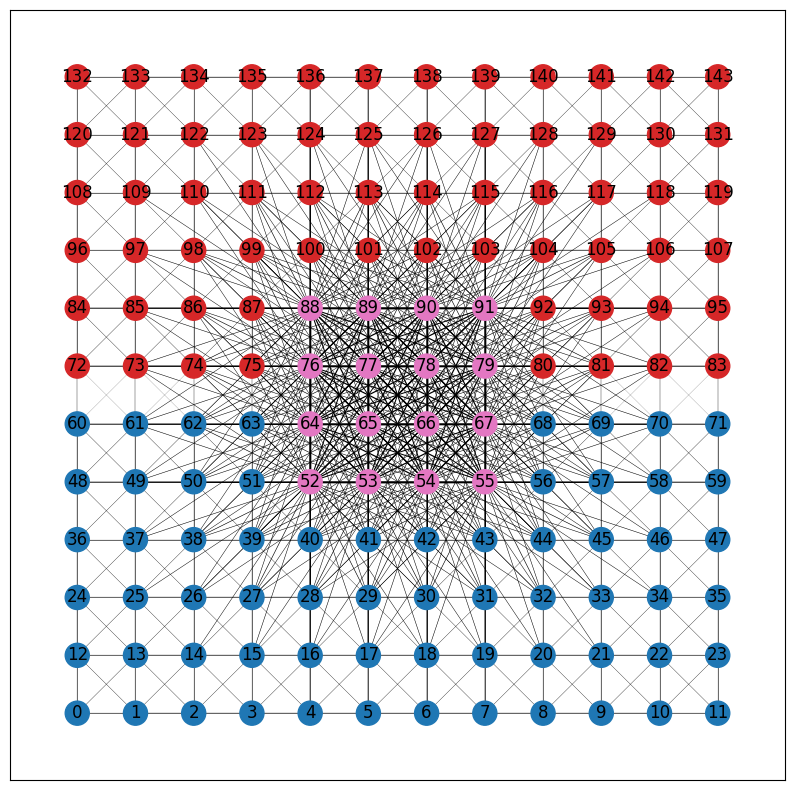

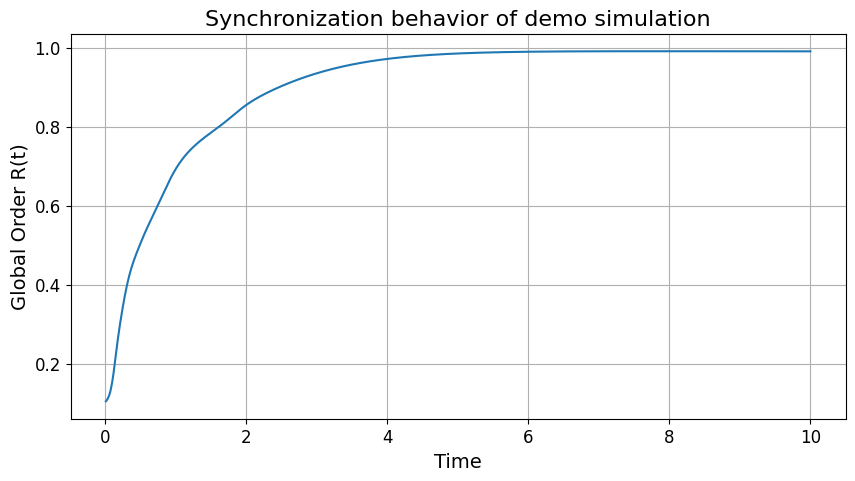

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R, 
    grads_mean_R, 
    node_importance_from_gradK, 
    grads_final_R_alpha,
    grads_mean_R_alpha,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    plot_graph_metrics
)

from jax import numpy as jnp

SUPTITLE_SIZE = 20
plt.rcParams.update({
    "font.size": 14,
    "figure.titlesize": 20,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

SEED = 42
grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape

group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids[n_rows // 2 -2: n_rows // 2 +2, n_cols // 2 -2: n_cols // 2 +2] = 2 # 3x3 block in center is group 2
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig( # Fully connected coupling from group 2 to groups 0 and 1
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="outgoing",
    ),
    KernelComponentConfig( 
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="incoming",
    ),
    KernelComponentConfig( # weak one way coupling from group 1 to group 0
        kernel="gaussian",
        base_strength=0.2,
        kernel_params={"sigma": 2.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run simulation
results = sim.run((0, T_END), dt, rng=RNG)

# Visualize base network
G = create_cortical_graph(sim)

plot_cortical_graph(G, layout="grid")


# Postprocess
R_list, _ = order_parameter(results['theta'])

fig,ax = plt.subplots(figsize=(10,5))
ax.plot(results['ts'], R_list, linewidth=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Global Order R(t)")
ax.set_title("Synchronization behavior of demo simulation")
ax.grid(True)

### 1) Network theory metrics

Create derived graphs and evaluate relevant centrality / important metrics.

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

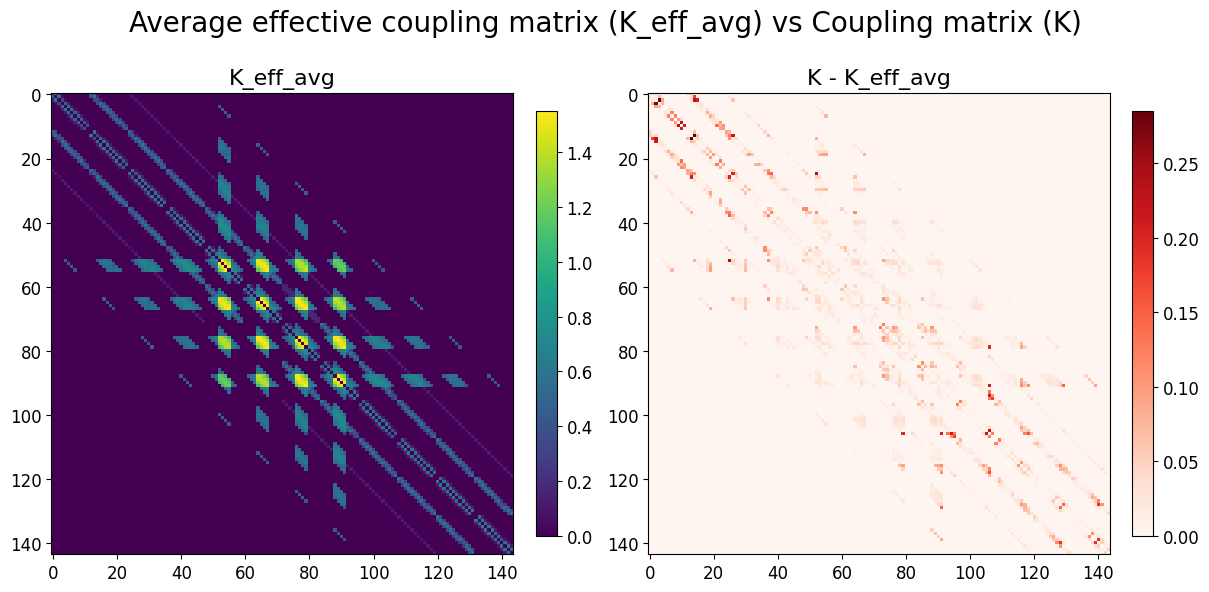

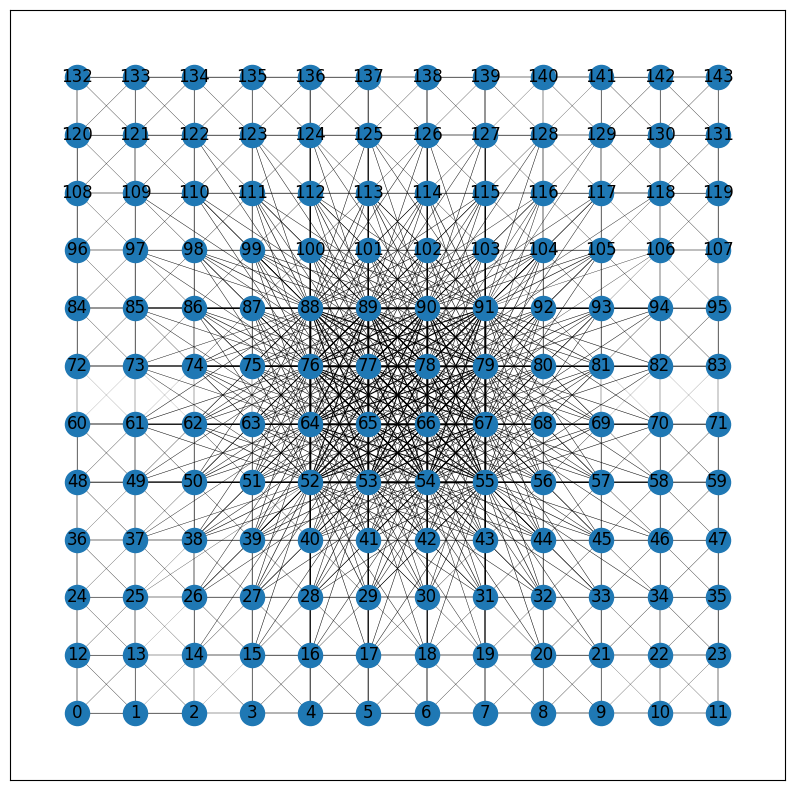

In [2]:
from matplotlib.colors import Normalize, CenteredNorm,TwoSlopeNorm

# K_eff_T = compute_effective_coupling(sim.results["theta"][-1], sim.coupling.K)
K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)

K_diff = sim.coupling.K - K_eff_avg

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(K_eff_avg, norm=Normalize(vmin=0, vmax=np.max(K_eff_avg)), cmap="viridis")
ax[0].set_title("K_eff_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)


if np.min(K_diff) < 0:
    norm=TwoSlopeNorm(vmin=np.min(K_diff),vcenter=0.0,vmax=np.max(K_diff))
    cmap="bwr"
else:
    norm=Normalize(vmin=0,vmax=np.max(K_diff))
    cmap="Reds"
im = ax[1].imshow(K_diff, norm=norm, cmap=cmap)
ax[1].set_title("K - K_eff_avg")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Average effective coupling matrix (K_eff_avg) vs Coupling matrix (K)")

G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

plot_cortical_graph(G_eff, layout="grid")

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

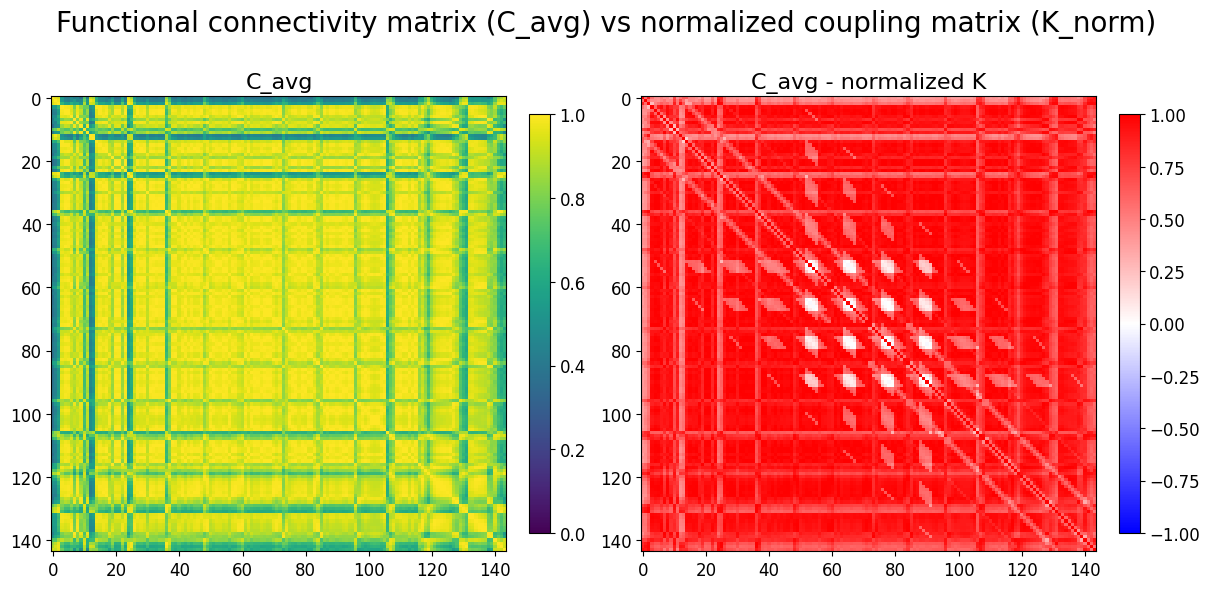

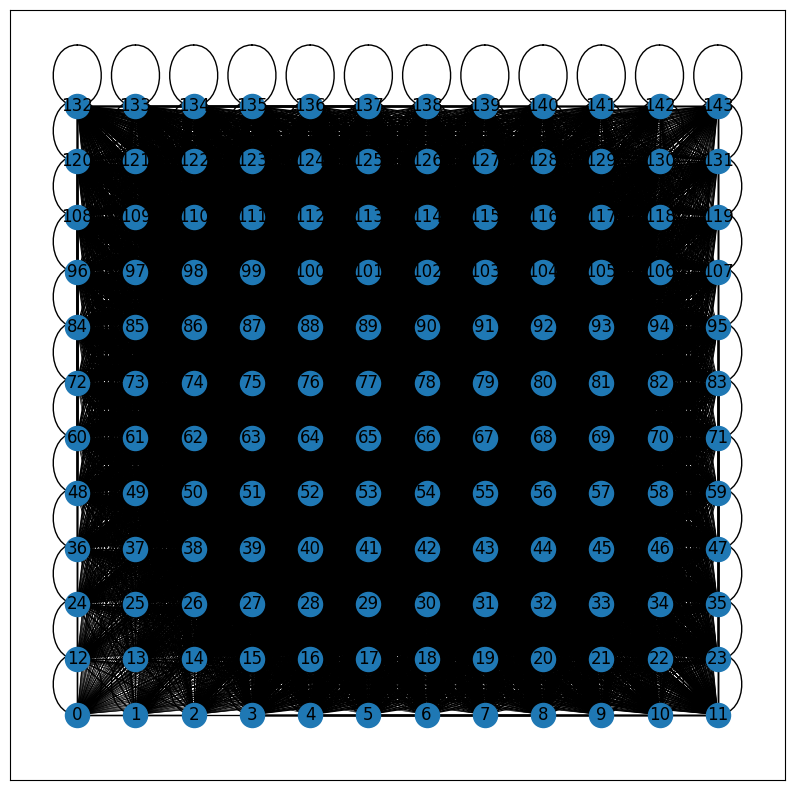

In [3]:
# Functional connectivity matrix
C_avg = functional_connectivity(sim.results["theta"], dt=dt)

# Compare with normalized coupling matrix
K_norm = sim.coupling.K / np.max(sim.coupling.K) # [0,1]

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(C_avg, norm=Normalize(vmin=0,vmax=1), cmap="viridis")
ax[0].set_title("C_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(C_avg-K_norm, norm=CenteredNorm(), cmap="bwr")
ax[1].set_title("C_avg - normalized K")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Functional connectivity matrix (C_avg) vs normalized coupling matrix (K_norm)")

G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

plot_cortical_graph(G_C_avg,layout="grid")

Text(0, 0.5, 'Functional Connectivity Graph')

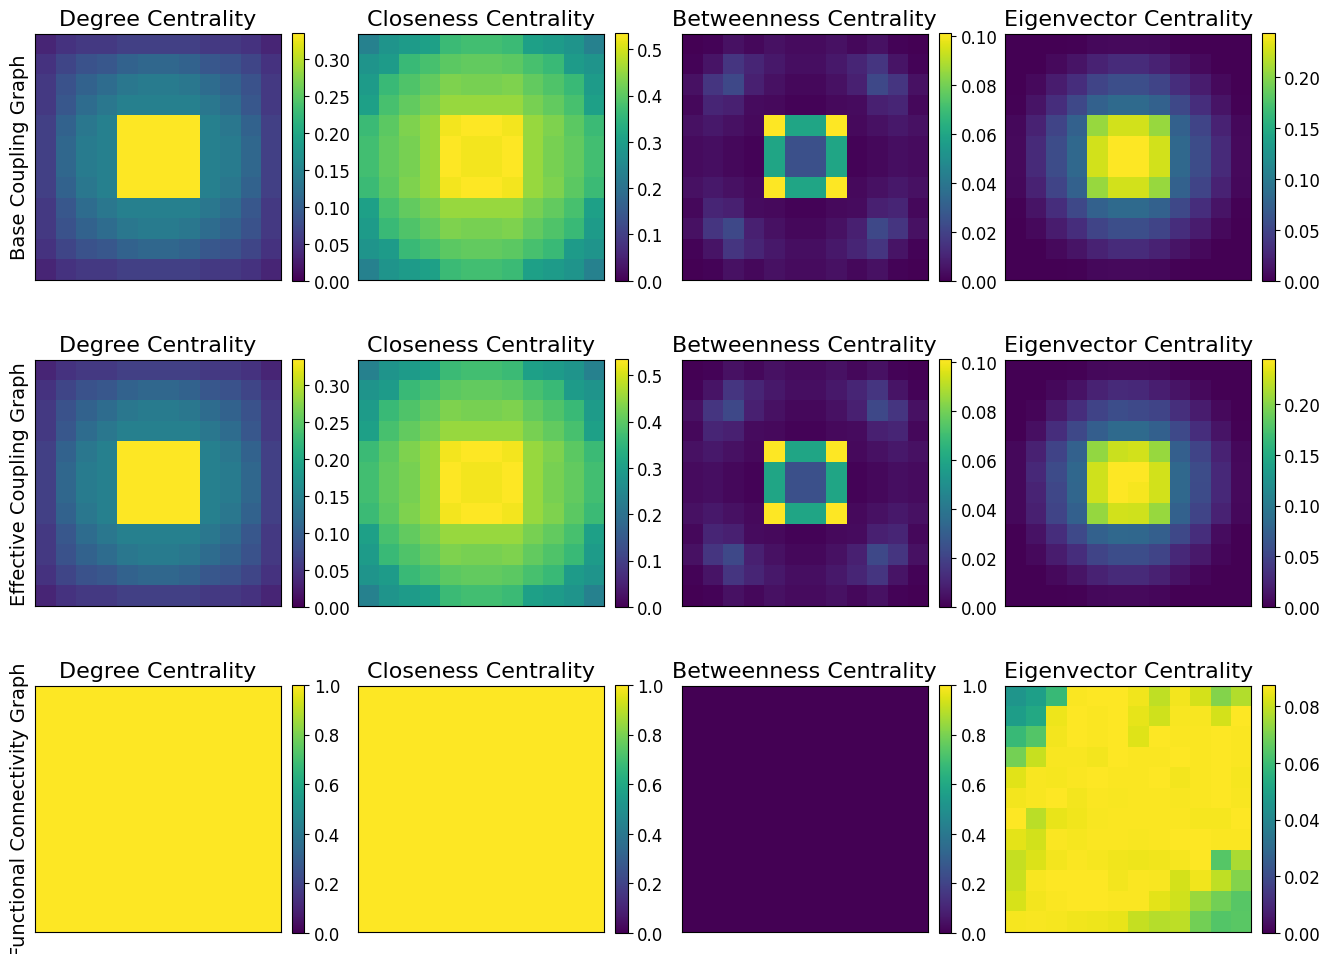

In [10]:
fig,axs = plt.subplots(3,4,figsize=(16,12))

plot_graph_metrics(G=G,grid_shape=grid_shape,axs=axs[0,:])
plot_graph_metrics(G=G_eff,grid_shape=grid_shape,axs=axs[1,:])
plot_graph_metrics(G=G_C_avg,grid_shape=grid_shape,axs=axs[2,:])

axs[0,0].set_ylabel("Base Coupling Graph")
axs[1,0].set_ylabel("Effective Coupling Graph")
axs[2,0].set_ylabel("Functional Connectivity Graph")

### 2) Adjoint metrics

  max |dR/dK| = 3.881817e-03
  max |dR/domega| = 6.043590e-03
  max |dR/dK| (averaged) = 7.509975e-02
  max |dR/domega| (averaged) = 7.545997e-02


Text(0.5, 0.98, 'Adjoint gradients')

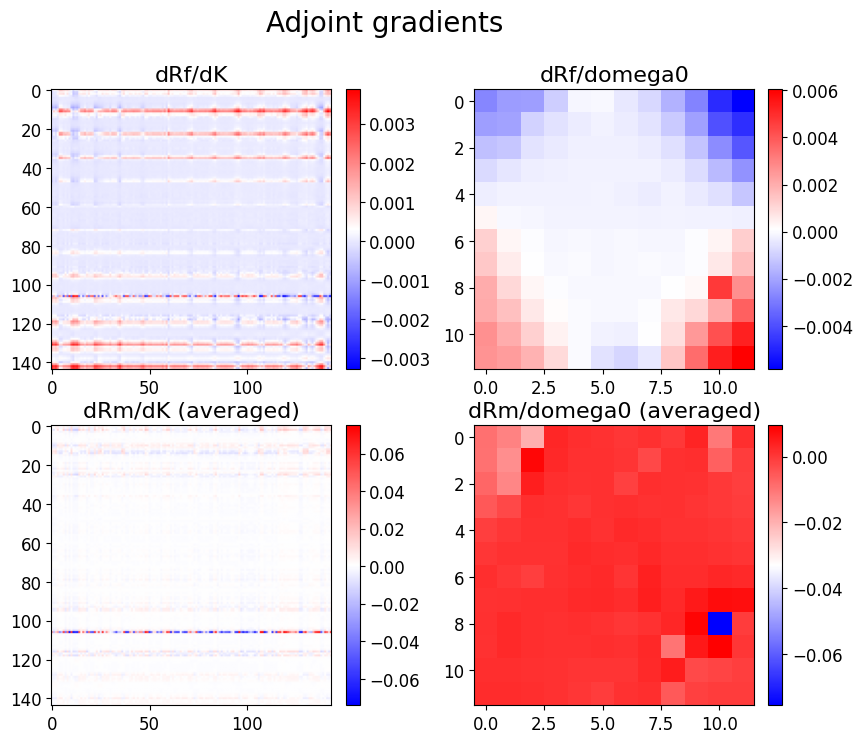

In [15]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

dR_dK = np.asarray(g.K)
dR_domega = np.asarray(g.omega)

dR_dK_avg = np.asarray(g_avg.K)
dR_domega_avg = np.asarray(g_avg.omega)

dR_domega_2d = sim.grid.unflatten(dR_domega)
dR_domega_avg_2d = sim.grid.unflatten(dR_domega_avg)

# Statistics
print(f"  max |dR/dK| = {float(np.max(np.abs(dR_dK))):.6e}")
print(f"  max |dR/domega| = {float(np.max(np.abs(dR_domega))):.6e}")
print(f"  max |dR/dK| (averaged) = {float(np.max(np.abs(dR_dK_avg))):.6e}")
print(f"  max |dR/domega| (averaged) = {float(np.max(np.abs(dR_domega_avg))):.6e}")

# Plot coupling matrix
fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.ravel()

im = axs[0].imshow(dR_dK, cmap="bwr")
axs[0].set_title("dRf/dK")
fig.colorbar(im,ax=axs[0],fraction=0.046, pad=0.04)

im = axs[1].imshow(dR_domega_2d, cmap="bwr")
axs[1].set_title("dRf/domega0")
fig.colorbar(im,ax=axs[1],fraction=0.046, pad=0.04)  

im = axs[2].imshow(dR_dK_avg, cmap="bwr")
axs[2].set_title("dRm/dK (averaged)")
fig.colorbar(im,ax=axs[2],fraction=0.046, pad=0.04)

im = axs[3].imshow(dR_domega_avg_2d, cmap="bwr")
axs[3].set_title("dRm/domega0 (averaged)")
fig.colorbar(im,ax=axs[3],fraction=0.046, pad=0.04)
fig.suptitle("Adjoint gradients")

  max I_final: 2.463365e-03
  max I_mean: 5.458221e-02
  max |dRf/dalpha| = 2.463365e-03
  max |dRm/dalpha| = 5.458221e-02


Text(0.5, 0.98, 'Adjoint node importance metrics')

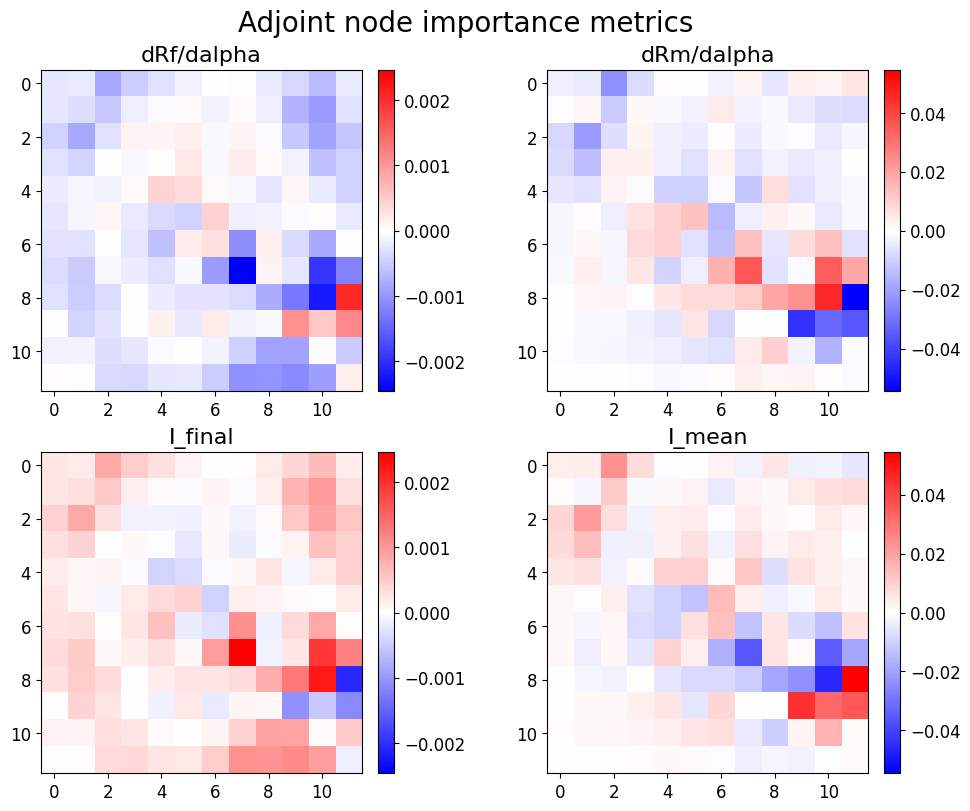

In [19]:
I_final = node_importance_from_gradK(sim.params.K, g.K)
I_mean = node_importance_from_gradK(sim.params.K, g_avg.K)

alpha0 = jnp.zeros((sim.grid.N,), dtype=sim.params.K.dtype)
dRf_dalpha = grads_final_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

#Statistics
print(f"  max I_final: {float(np.max(I_final)):.6e}")
print(f"  max I_mean: {float(np.max(I_mean)):.6e}")
print(f"  max |dRf/dalpha| = {float(np.max(np.abs(dRf_dalpha))):.6e}")
print(f"  max |dRm/dalpha| = {float(np.max(np.abs(dRm_dalpha))):.6e}")

#Plot
fig,ax = plt.subplots(2,2,figsize=(10,8),constrained_layout=True)
ax = ax.ravel()

im = ax[0].imshow(dRf_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
ax[0].set_title("dRf/dalpha")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(dRm_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
ax[1].set_title("dRm/dalpha")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)

im = ax[2].imshow(I_final.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
ax[2].set_title("I_final")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)

im = ax[3].imshow(I_mean.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
ax[3].set_title("I_mean")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)
fig.suptitle("Adjoint node importance metrics")